In [ ]:
import os
from pathlib import Path
import matplotlib.pyplot as plt

_TREBL_FIG_DIR = Path.cwd() / 'saved_figures'
_TREBL_FIG_DIR.mkdir(parents=True, exist_ok=True)


def _trebl_notebook_stem():
    session_path = os.environ.get('JPY_SESSION_NAME', '')
    if session_path:
        raw_stem = Path(session_path).stem or 'notebook'
        safe_stem = ''.join(ch if (ch.isalnum() or ch in {'_', '-'}) else '_' for ch in raw_stem)
        return safe_stem.strip('_') or 'notebook'
    return 'notebook'


# Reset counter and stem every time this cell runs so re-running replaces existing images
if hasattr(plt, '_trebl_autosave_original_show'):
    plt.show = plt._trebl_autosave_original_show

plt._trebl_autosave_original_show = plt.show
plt._trebl_autosave_counter = 1
plt._trebl_notebook_stem = _trebl_notebook_stem()


def _trebl_autosave_show(*args, **kwargs):
    for fig_num in plt.get_fignums():
        fig = plt.figure(fig_num)
        stem = f"{plt._trebl_notebook_stem}_figure_{plt._trebl_autosave_counter:04d}"
        fig.savefig(_TREBL_FIG_DIR / f'{stem}.png', dpi=300, bbox_inches='tight')
        fig.savefig(_TREBL_FIG_DIR / f'{stem}.pdf', dpi=300, bbox_inches='tight')
        plt._trebl_autosave_counter += 1
    return plt._trebl_autosave_original_show(*args, **kwargs)


plt.show = _trebl_autosave_show


In [727]:
import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy
import seaborn as sns

# Exploring speed fits
1. Exponential
2. Hill
3. Time first active

## Loading in activities

In [1175]:
dbd_norm_activities = pd.read_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/ChopTFs_pipeline/time_normalization/DBD_time_normalized_activities_error_propagated.csv")
# dbd_norm_activities = dbd_norm_activities[["ADseq",  "time", "rep", "z-scored_activity", "shifted_activity"]]
# dbd_norm_activities = dbd_norm_activities.groupby(["ADseq", "rep", "time"])[["shifted_activity"]].agg(["mean", "std"]).reset_index()
# dbd_norm_activities.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in dbd_norm_activities.columns]
# dbd_norm_activities = dbd_norm_activities[dbd_norm_activities["rep_"] == 2]
# dbd_norm_activities = dbd_norm_activities.dropna()
# activities = dbd_norm_activities
# activities = activities.rename(columns = {"ADseq_" : "ADseq", "time_" : "time"})
dbd_norm_activities = dbd_norm_activities[["ADseq", "time", "grand_mean", "SE_final"]]
dbd_norm_activities = dbd_norm_activities.dropna()
activities = dbd_norm_activities
activities = activities.rename(columns = {"grand_mean" : "activity", "SE_final" : "error"})
activities

,ADseq,time,activity,error
2,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,0,0.191781,0.046523
3,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,0.356032,0.102500
4,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,5,0.469725,0.193822
5,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,10,0.194010,0.153025
6,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,15,0.173738,0.118937
...,...,...,...,...
164679,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,60,0.736019,0.137452
164682,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,5,-0.114355,0.507444
164683,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,10,-0.040065,0.211361
164685,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,20,0.296599,0.502719


In [1176]:
activities["ADseq"].value_counts()

ADseq
YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH    10
AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS    10
AAAAAIQEQQQLLQQKQQDDDDAIAAAAAAASSSLGDNKD    10
AAAANNAAGPASYLSQLPQVQRYYPNNMNALSSLLDPSSA    10
AAAASTSKSAEKEKPVTKKELKRREKQALLEKKKKLLEIA    10
                                            ..
RSPNIGMCTVNYKSNLPLQVSAVDQLSTGKGTQFYGHNSY     1
RTACKRCRLKKIKCDQEFPSCKRCAKLEVPCVSLDPATGK     1
IPNELRQMAQIARFENQIVNTMNSTPASVTGMVSQEEKQP     1
KSSNLLLRYRRSIDLANDRRIPDFITIPNRFIHDMDNDQT     1
KSSYKSLDFEEAIRRRRMWWHCFCTDKLYSLMLSRPPIVG     1
Name: count, Length: 13939, dtype: int64

In [1179]:
# Error should be <75% of measured activity
activities["rel_error"] = activities["error"] / activities["activity"]
activities = activities[activities["rel_error"] < 1]
activities

/tmp/ipykernel_2472489/468145238.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  activities["rel_error"] = activities["error"] / activities["activity"]


,ADseq,time,activity,error,rel_error
2,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,0,0.191781,0.046523,0.242583
3,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,0.356032,0.102500,0.287897
4,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,5,0.469725,0.193822,0.412628
5,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,10,0.194010,0.153025,0.788747
6,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,15,0.173738,0.118937,0.684576
...,...,...,...,...,...
164677,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,40,0.753709,0.084206,0.111722
164678,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,50,0.674905,0.045527,0.067457
164679,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,60,0.736019,0.137452,0.186751
164682,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,5,-0.114355,0.507444,-4.437429


In [1181]:
activities["ADseq"].value_counts()

ADseq
YQVQESFQSSGSDSNASNPPSTSVGVPSNATATALPNGSA    10
MQWNTAVSPYSSRAPSTTAKNYPPSTFYSQNINQYPRRRT    10
AAERQYNGEASSASTHPTLPNMNISNGSGSAGASSSMLSY    10
MRQRRSVVAVSVKPKGFKLGHKQGSMSTTSPPPSSPDGNV    10
MNINPSVRDYNKPVPQNMAPSPIYPINEPTTRLYSQPKMR    10
                                            ..
MRNMIENDVNNIDSLEPPYVMKKYHTSLGLPSLVNAKDHF     1
MPSGHNDKNANQESVEEAVLKYVGVGLDHQNHDPQLHTKD     1
MPSMAQPLNESCLNARPSKRRSKVALGAPNSGASISPIKS     1
YSDIDVDGLCSELMAKAKCSERGVVINAEDVQLALNKHMN     1
KSSYKSLDFEEAIRRRRMWWHCFCTDKLYSLMLSRPPIVG     1
Name: count, Length: 13836, dtype: int64

In [1182]:
#activities.to_csv("../../../output/ChopTFs_activities_for_julieta.csv")

In [1183]:
len(activities["ADseq"].unique())

13836

In [1184]:
threshold = np.percentile(activities[activities["time"] == 0]["activity"], 99)
threshold

0.6655100361481406

In [1185]:
active_tiles = activities[activities["activity"] >= threshold]["ADseq"].unique()
len(active_tiles)

1957

In [1186]:
active_tile_activities = activities[activities["ADseq"].isin(active_tiles)]
active_tile_activities

,ADseq,time,activity,error,rel_error
173,AAHHDNSTIPLDFMPRDALHGFDWSEEDDMSDGLPFLKTD,5,0.559973,0.138607,0.247524
174,AAHHDNSTIPLDFMPRDALHGFDWSEEDDMSDGLPFLKTD,10,1.187506,0.028902,0.024338
175,AAHHDNSTIPLDFMPRDALHGFDWSEEDDMSDGLPFLKTD,15,1.246238,0.051573,0.041383
176,AAHHDNSTIPLDFMPRDALHGFDWSEEDDMSDGLPFLKTD,20,1.462355,0.038328,0.026210
177,AAHHDNSTIPLDFMPRDALHGFDWSEEDDMSDGLPFLKTD,30,1.513140,0.055333,0.036569
...,...,...,...,...,...
164675,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,20,0.509713,0.037498,0.073566
164676,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,30,0.647967,0.077280,0.119266
164677,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,40,0.753709,0.084206,0.111722
164678,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,50,0.674905,0.045527,0.067457


In [1187]:
active_tile_activities["ADseq"].value_counts()

ADseq
YFGSIGDISELYLRVEQYWDRRADKNHSVDGKYWDALIWS    10
YFYVSEHLDPESPDCVLSPTNLLTLHHLLNLSMTLGLQYE    10
YGSLHSLQKGNEADLADDGLNTNDISSEDFAEEAPINLFG    10
YDSTFYLHRDHVNYEEYGVDSLLFSYPEDSIQKVARYERV    10
WTGSLDPNLKKGKWTQEEDEQLLKAYEEHGPHWLSISMDI    10
                                            ..
ELTSRAGKKFDRRDITIVDDSGFSISVGLWNQQALDFNLP     1
MPSGHNDKNANQESVEEAVLKYVGVGLDHQNHDPQLHTKD     1
RSFMKTDESLPELFERNYASTNNLDLSLMATAENIYHLHL     1
RYSLNAPKYSSQPPPASHTYLPPMSVNIPPIASKSSSIYS     1
AKTDSEVNESQYLHSNQPNSTNMNTIMEDLSNINSFVTSS     1
Name: count, Length: 1957, dtype: int64

In [1188]:
import pandas as pd

# filter to ADs with at least 4 time points

# assuming your DataFrame is called df
active_tile_activities_count_filtered = active_tile_activities.groupby('ADseq').filter(lambda x: len(x) >= 5)

active_tile_activities_count_filtered

,ADseq,time,activity,error,rel_error
173,AAHHDNSTIPLDFMPRDALHGFDWSEEDDMSDGLPFLKTD,5,0.559973,0.138607,0.247524
174,AAHHDNSTIPLDFMPRDALHGFDWSEEDDMSDGLPFLKTD,10,1.187506,0.028902,0.024338
175,AAHHDNSTIPLDFMPRDALHGFDWSEEDDMSDGLPFLKTD,15,1.246238,0.051573,0.041383
176,AAHHDNSTIPLDFMPRDALHGFDWSEEDDMSDGLPFLKTD,20,1.462355,0.038328,0.026210
177,AAHHDNSTIPLDFMPRDALHGFDWSEEDDMSDGLPFLKTD,30,1.513140,0.055333,0.036569
...,...,...,...,...,...
164675,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,20,0.509713,0.037498,0.073566
164676,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,30,0.647967,0.077280,0.119266
164677,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,40,0.753709,0.084206,0.111722
164678,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,50,0.674905,0.045527,0.067457


In [1119]:
# --- further filter to ensure time=0 exists ---
active_tile_activities_count_filtered = active_tile_activities_count_filtered.groupby('ADseq').filter(lambda x: 0 in x['time'].values)

active_tile_activities_count_filtered

,ADseq,time,activity,error,rel_error
211,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,0,-0.401863,0.154351,-0.384089
214,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,10,0.422440,0.228252,0.540318
215,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,15,0.786688,0.048011,0.061029
216,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,20,0.566518,0.144341,0.254785
217,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,30,0.708234,0.132258,0.186744
...,...,...,...,...,...
164675,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,20,0.509713,0.037498,0.073566
164676,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,30,0.647967,0.077280,0.119266
164677,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,40,0.753709,0.084206,0.111722
164678,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,50,0.674905,0.045527,0.067457


In [1120]:
# import pandas as pd

# # Make sure 'time' is numeric and sorted
# active_tile_activities_count_filtered = active_tile_activities_count_filtered.copy()
# active_tile_activities_count_filtered['time'] = pd.to_numeric(active_tile_activities_count_filtered['time'], errors='coerce')

# def has_4_of_5_first_times(grp):
#     # first 5 time points in sorted order
#     first_5_times = sorted(grp['time'].unique())[:5]
#     # count how many are actually present
#     n_present = sum(t in grp['time'].values for t in first_5_times)
#     return n_present >= 4

# # filter the DataFrame
# active_tile_activities_count_filtered = active_tile_activities_count_filtered.groupby('ADseq').filter(has_4_of_5_first_times)

# active_tile_activities_count_filtered

In [1121]:
active_tile_activities_count_filtered["ADseq"].value_counts()

ADseq
AKPATSPTNVGTLHENLSSSHFMIPDVDQFNSFEDFFQDF    10
AKDTQDEEYVQHHDNVNPTIPPPDNYILNNENDDGLDNLL    10
AIVSSLRDNILYPYLIYSPHLNDQTKALLTDISNWSCFAL    10
YLHRDHVNYEEYGVDSLLFSYPEDSIQKVARYERVQFASS    10
YFGSIGDISELYLRVEQYWDRRADKNHSVDGKYWDALIWS    10
                                            ..
SVLEQPLHNCKHPTFERTGQLGDVMKESSRLAYSFAKMYL     5
DKISSDGEIPPKVQQAVRLKWGLDCNNSRRIKQKLISSQS     5
AIAALGSLISYKSETELFQQSEVFYQRAKTIVLKKIFQLE     5
CAFCRKRKLKCSQARPMCQQCVIRKLPQCVYTEEFNYPLS     5
AKLTQTRKVKKPNSVVKKSHHVGKDDESRLDHLGVVAYNR     5
Name: count, Length: 1183, dtype: int64

# multiple fits

In [1163]:
# import numpy as np
# import pandas as pd
# from scipy.optimize import curve_fit
# import tqdm
# import warnings
# from numpy import RankWarning

# # ----------------------------
# # Models
# # ----------------------------
# def constant_model(t, c):
#     return np.full_like(t, c)

# def linear_model(t, m, b):
#     return m * t + b

# def exp_model(t, Amax, k):
#     return Amax * (1 - np.exp(-k * t))

# def logistic_model(t, Amax, k, t0):
#     return Amax / (1 + np.exp(-k * (t - t0)))

# # ----------------------------
# # Model-based initial slope
# # ----------------------------
# def model_initial_slope(params, model_name):
#     if model_name == "exp":
#         Amax, k = params
#         return Amax * k
#     elif model_name == "logistic":
#         Amax, k, t0 = params
#         return k * Amax / 4
#     elif model_name == "linear":
#         m, _ = params
#         return m
#     else:  # constant
#         return 0.0

# # ----------------------------
# # Compute AIC
# # ----------------------------
# def compute_aic(y, y_pred, k_params):
#     n = len(y)
#     rss = np.sum((y - y_pred)**2)
#     if rss == 0:
#         rss = 1e-12
#     return n * np.log(rss / n) + 2 * k_params

# # ----------------------------
# # Fit wrappers
# # ----------------------------
# def fit_constant(t, y, err=None):
#     c = np.mean(y)
#     y_pred = constant_model(t, c)
#     return (c,), y_pred

# def fit_linear(t, y, err=None):
#     t = np.array(t)
#     y = np.array(y)
#     if err is not None:
#         err = np.array(err)
#         mask = np.isfinite(t) & np.isfinite(y) & np.isfinite(err)
#         t, y, err = t[mask], y[mask], err[mask]
#         w = 1 / np.clip(err, 1e-8, None)
#         m, b = np.polyfit(t, y, 1, w=w)
#     else:
#         m, b = np.polyfit(t, y, 1)
#     y_pred = linear_model(t, m, b)
#     return (m, b), y_pred

# def fit_exp(t, y, err=None):
#     p0 = [np.max(y), 0.1]
#     bounds = (0, [np.inf, np.inf])
#     if err is not None:
#         err = np.array(err)
#         mask = np.isfinite(t) & np.isfinite(y) & np.isfinite(err)
#         t, y, err = t[mask], y[mask], err[mask]
#         err = np.clip(err, 1e-8, None)
#     try:
#         popt, _ = curve_fit(
#             exp_model, t, y, p0=p0, bounds=bounds,
#             sigma=err, absolute_sigma=True if err is not None else False,
#             maxfev=10000
#         )
#     except Exception:
#         return None, None
#     y_pred = exp_model(t, *popt)
#     return popt, y_pred

# def fit_logistic(t, y, err=None):
#     p0 = [np.max(y), 0.1, np.median(t)]
#     bounds = (0, [np.inf, np.inf, np.max(t)*2])
#     if err is not None:
#         err = np.array(err)
#         mask = np.isfinite(t) & np.isfinite(y) & np.isfinite(err)
#         t, y, err = t[mask], y[mask], err[mask]
#         err = np.clip(err, 1e-8, None)
#     try:
#         popt, _ = curve_fit(
#             logistic_model, t, y, p0=p0, bounds=bounds,
#             sigma=err, absolute_sigma=True if err is not None else False,
#             maxfev=10000
#         )
#     except Exception:
#         return None, None
#     y_pred = logistic_model(t, *popt)
#     return popt, y_pred

# # ----------------------------
# # Analyze a single sequence
# # ----------------------------
# def analyze_sequence(g):
#     g = g.sort_values("time")
#     t = g["time"].values
#     y = g["activity"].values
#     err = g["error"].values if "error" in g else None

#     models = {
#         "constant": (fit_constant, 1),
#         "linear": (fit_linear, 2),
#         "exp": (fit_exp, 2),
#         "logistic": (fit_logistic, 3),
#     }

#     results = []

#     for name, (fn, k_params) in models.items():
#         try:
#             params, y_pred = fn(t, y, err)
#             if params is None:
#                 results.append((name, np.nan, np.nan, np.nan))
#                 continue
#             speed = model_initial_slope(params, name)
#             if name in ["exp", "logistic"]:
#                 strength = params[0]
#             elif name == "linear":
#                 strength = np.max(y)
#             else:
#                 strength = params[0]
#             aic = compute_aic(y, y_pred, k_params)
#             results.append((name, speed, strength, aic))
#         except Exception:
#             results.append((name, np.nan, np.nan, np.nan))

#     return results

# # ----------------------------
# # Analyze all sequences
# # ----------------------------
# def analyze_all(df):
#     all_results = []
#     for seq, g in tqdm.tqdm(df.groupby("ADseq")):
#         seq_results = analyze_sequence(g)
#         for name, speed, strength, aic in seq_results:
#             all_results.append({
#                 "ADseq": seq,
#                 "model": name,
#                 "speed": speed,
#                 "strength": strength,
#                 "aic": aic
#             })
#     return pd.DataFrame(all_results)

In [1164]:
# results = analyze_all(active_tile_activities)
# results

In [1165]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import warnings
from numpy import RankWarning
from joblib import Parallel, delayed
import tqdm

warnings.simplefilter('ignore', RankWarning)
warnings.simplefilter('ignore', RuntimeWarning)

# ----------------------------
# Models
# ----------------------------
def constant_model(t, c):
    return np.full_like(t, c)

def linear_model(t, m, b):
    return m * t + b

def exp_model(t, Amax, k):
    return Amax * (1 - np.exp(-k * t))

def logistic_model(t, Amax, k, t0):
    return Amax / (1 + np.exp(-k * (t - t0)))

# ----------------------------
# Speed / strength / half-max
# ----------------------------
def model_initial_slope(params, model_name, t0=0):
    if model_name == "exp":
        Amax, k = params
        return Amax * k
    elif model_name == "logistic":
        Amax, k, t_mid = params
        return Amax * k * np.exp(-k*(t0 - t_mid)) / (1 + np.exp(-k*(t0 - t_mid)))**2
    elif model_name == "linear":
        m, _ = params
        return m
    else:
        return 0.0

def model_strength(params, model_name, t=None):
    if model_name == "exp":
        y_pred = exp_model(t, *params)
    elif model_name == "logistic":
        y_pred = logistic_model(t, *params)
    elif model_name == "linear":
        y_pred = linear_model(t, *params)
    else:
        y_pred = constant_model(t, *params)
    return np.max(y_pred)
    
def model_thalf(params, model_name, t=None):
    """
    Compute the half-max time using model parameters and optional t vector.
    If t is provided, computes half-max numerically using predicted curve.
    """
    try:
        if model_name == "exp":
            Amax, k = params
            return np.log(2)/k
        elif model_name == "logistic":
            # t_mid is the half-max analytically
            return params[2]
        elif model_name in ["linear", "constant"]:
            if t is None:
                return np.nan
            # numerical half-max
            if model_name == "linear":
                y_pred = linear_model(t, *params)
            else:
                y_pred = constant_model(t, *params)
            half_max = np.max(y_pred) / 2
            # find first time reaching half-max
            idx = np.where(y_pred >= half_max)[0]
            return t[idx[0]] if len(idx) > 0 else np.nan
        else:
            return np.nan
    except Exception:
        return np.nan

# ----------------------------
# Activation time
# ----------------------------
threshold = np.percentile(activities[activities["time"] == 0]["activity"], 99)

def activation_time(t, y, threshold=threshold):
    t = np.array(t)
    y = np.array(y)
    if threshold is None:
        threshold = np.percentile(y[t==0], 99)
    above = np.where(y > threshold)[0]
    return t[above[0]] if len(above) > 0 else np.nan

# ----------------------------
# Goodness-of-fit
# ----------------------------
def compute_aic(y, y_pred, k_params):
    n = len(y)
    rss = np.sum((y - y_pred)**2)
    rss = max(rss, 1e-12)
    return n * np.log(rss / n) + 2 * k_params

def compute_r2(y, y_pred):
    ss_res = np.sum((y - y_pred)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    return 1 - ss_res/ss_tot if ss_tot != 0 else np.nan

def compute_nrmse(y, y_pred):
    return np.sqrt(np.mean((y - y_pred)**2)) / (np.ptp(y) + 1e-12)

# ----------------------------
# Fit wrappers
# ----------------------------
def fit_constant(t, y, err=None):
    c = np.mean(y)
    return (c,), constant_model(t, c)

def fit_linear(t, y, err=None):
    if err is not None:
        err = np.clip(err, 1e-8, None)
        mask = np.isfinite(t) & np.isfinite(y) & np.isfinite(err)
        t, y, err = t[mask], y[mask], err[mask]
        m, b = np.polyfit(t, y, 1, w=1/err)
    else:
        m, b = np.polyfit(t, y, 1)
    return (m, b), linear_model(t, m, b)

def fit_exp(t, y, err=None):
    p0 = [np.max(y), 0.1]
    bounds = (0, [np.inf, np.inf])
    try:
        popt, _ = curve_fit(exp_model, t, y, p0=p0, bounds=bounds,
                            sigma=err, absolute_sigma=err is not None,
                            maxfev=5000)
    except Exception:
        return None, None
    return popt, exp_model(t, *popt)

def fit_logistic(t, y, err=None):
    p0 = [np.max(y), 0.1, np.median(t)]
    bounds = (0, [np.inf, np.inf, np.max(t)*2])
    try:
        popt, _ = curve_fit(logistic_model, t, y, p0=p0, bounds=bounds,
                            sigma=err, absolute_sigma=err is not None,
                            maxfev=5000)
    except Exception:
        return None, None
    return popt, logistic_model(t, *popt)

# ----------------------------
# Analyze single sequence
# ----------------------------
def analyze_sequence(g):
    g = g.sort_values("time")
    t = g["time"].values
    y = g["activity"].values
    err = g["error"].values if "error" in g else None

    models = {
        "constant": (fit_constant, 1),
        "linear": (fit_linear, 2),
        "exp": (fit_exp, 2),
        "logistic": (fit_logistic, 3)
    }

    results = []
    for name, (fn, k_params) in models.items():
        try:
            params, y_pred = fn(t, y, err)
            if params is None:
                continue
            results.append({
                "model": name,
                "params": params,
                "y_pred": y_pred,
                "speed": model_initial_slope(params, name),
                "strength": model_strength(params, name, y_obs=y),
                "t_half_max": model_thalf(params, name, t=t),
                "activation_time": activation_time(t, y),
                "aic": compute_aic(y, y_pred, k_params),
                "r2": compute_r2(y, y_pred),
                "nrmse": compute_nrmse(y, y_pred)
            })
        except Exception:
            continue

    if len(results) == 0:
        return None

    # best model by AIC
    best = min(results, key=lambda r: r["aic"])
    best["ADseq"] = g["ADseq"].iloc[0]
    return best

# ----------------------------
# Parallel analysis across sequences
# ----------------------------
# ----------------------------
# Analyze single sequence (all models)
# ----------------------------
def analyze_sequence_all(g):
    g = g.sort_values("time")
    t = g["time"].values
    y = g["activity"].values
    err = g["error"].values if "error" in g else None

    models = {
        "constant": (fit_constant, 1),
        "linear": (fit_linear, 2),
        "exp": (fit_exp, 2),
        "logistic": (fit_logistic, 3)
    }

    results = []
    for name, (fn, k_params) in models.items():
        try:
            params, y_pred = fn(t, y, err)
            if params is None:
                continue
            results.append({
                "ADseq": g["ADseq"].iloc[0],   # add sequence ID
                "model": name,
                "params": params,
                "y_pred": y_pred,
                "speed": model_initial_slope(params, name),
                "strength": model_strength(params, name, t=t),  # max predicted over time
                "t_half_max": model_thalf(params, name),
                "activation_time": activation_time(t, y),
                "aic": compute_aic(y, y_pred, k_params),
                "r2": compute_r2(y, y_pred),
                "nrmse": compute_nrmse(y, y_pred)
            })
        except Exception:
            continue

    if len(results) == 0:
        return None

    return results  # return all models, not just the best

# ----------------------------
# Parallel analysis across sequences (all models)
# ----------------------------
def analyze_all_parallel(df, n_jobs=-1):
    sequences = [g for _, g in df.groupby("ADseq")]

    all_results_list = Parallel(n_jobs=n_jobs)(
        delayed(analyze_sequence_all)(g) for g in tqdm.tqdm(sequences)
    )

    # flatten into a single list of dicts
    all_results = []
    for seq_res in all_results_list:
        if seq_res is not None:
            all_results.extend(seq_res)  # extend instead of append
    return pd.DataFrame(all_results)

In [1166]:
results = analyze_all_parallel(active_tile_activities_count_filtered)
results


100%|██████████| 1183/1183 [00:28<00:00, 41.26it/s]


,ADseq,model,params,y_pred,speed,strength,t_half_max,activation_time,aic,r2,nrmse
0,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,constant,"(0.549608210547291,)","[0, 0, 0, 0, 0, 0, 0, 0]",0.000000e+00,0.000000,NaN,15,-4.448855,-2.090095,0.555475
1,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,linear,"(0.008368426851483349, 0.5128103219142556)","[0.5128103219142556, 0.596494590429089, 0.6383...",8.368427e-03,1.014916,NaN,15,-12.631197,0.134624,0.293955
2,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,exp,"[0.7666522734748318, 0.25121941768024164]","[0.0, 0.7044843502749516, 0.7489491326044606, ...",1.925979e-01,0.766652,2.759131,15,-22.561290,0.749889,0.158032
3,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,logistic,"[0.7625690105887741, 4.231405598981312, 9.9487...","[3.977724156342203e-19, 0.4224379068724006, 0....",1.683136e-18,0.762569,9.948785,15,-23.162125,0.819307,0.134322
4,AALGICNTRLLYPLEVIDKAFSTTNELAWALANQWSCVNI,constant,"(0.4255867984040508,)","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",0.000000e+00,0.000000,NaN,40,-12.323899,-3.143776,0.699659
...,...,...,...,...,...,...,...,...,...,...,...
4705,YVSKAKLQPAKPQFTNLTHPYELNLDRDTVIEECFDESNV,logistic,"[0.7554291284531978, 0.16231772753097315, 1.89...","[0.32004784737133507, 0.38090311844044605, 0.5...",2.994035e-02,0.755369,1.895983,20,-33.801853,0.663949,0.167676
4706,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,constant,"(0.43454020072298616,)","[0, 0, 0, 0, 0, 0, 0, 0, 0]",0.000000e+00,0.000000,NaN,40,-9.741360,-2.289983,0.675100
4707,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,linear,"(0.010097765921572709, 0.23368137960338817)","[0.23368137960338817, 0.25387691144653357, 0.3...",1.009777e-02,0.839547,NaN,40,-30.262458,0.730574,0.193193
4708,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,exp,"[0.7712942213405963, 0.04967823412122157]","[0.0, 0.07294908685785194, 0.3019729396067862,...",3.831653e-02,0.732145,13.952734,40,-42.275435,0.929082,0.099117


In [1167]:
results

,ADseq,model,params,y_pred,speed,strength,t_half_max,activation_time,aic,r2,nrmse
0,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,constant,"(0.549608210547291,)","[0, 0, 0, 0, 0, 0, 0, 0]",0.000000e+00,0.000000,NaN,15,-4.448855,-2.090095,0.555475
1,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,linear,"(0.008368426851483349, 0.5128103219142556)","[0.5128103219142556, 0.596494590429089, 0.6383...",8.368427e-03,1.014916,NaN,15,-12.631197,0.134624,0.293955
2,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,exp,"[0.7666522734748318, 0.25121941768024164]","[0.0, 0.7044843502749516, 0.7489491326044606, ...",1.925979e-01,0.766652,2.759131,15,-22.561290,0.749889,0.158032
3,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,logistic,"[0.7625690105887741, 4.231405598981312, 9.9487...","[3.977724156342203e-19, 0.4224379068724006, 0....",1.683136e-18,0.762569,9.948785,15,-23.162125,0.819307,0.134322
4,AALGICNTRLLYPLEVIDKAFSTTNELAWALANQWSCVNI,constant,"(0.4255867984040508,)","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",0.000000e+00,0.000000,NaN,40,-12.323899,-3.143776,0.699659
...,...,...,...,...,...,...,...,...,...,...,...
4705,YVSKAKLQPAKPQFTNLTHPYELNLDRDTVIEECFDESNV,logistic,"[0.7554291284531978, 0.16231772753097315, 1.89...","[0.32004784737133507, 0.38090311844044605, 0.5...",2.994035e-02,0.755369,1.895983,20,-33.801853,0.663949,0.167676
4706,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,constant,"(0.43454020072298616,)","[0, 0, 0, 0, 0, 0, 0, 0, 0]",0.000000e+00,0.000000,NaN,40,-9.741360,-2.289983,0.675100
4707,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,linear,"(0.010097765921572709, 0.23368137960338817)","[0.23368137960338817, 0.25387691144653357, 0.3...",1.009777e-02,0.839547,NaN,40,-30.262458,0.730574,0.193193
4708,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,exp,"[0.7712942213405963, 0.04967823412122157]","[0.0, 0.07294908685785194, 0.3019729396067862,...",3.831653e-02,0.732145,13.952734,40,-42.275435,0.929082,0.099117


In [1168]:
# df_all_models is your full results dataframe with all models per sequence
# Columns: model, speed, strength, t_half_max, activation_time, aic, ADseq

# Find the index of the row with minimum AIC for each ADseq
best_idx = results.groupby("ADseq")["aic"].idxmin()

# Extract the best-fit rows
df_best_fit = results.loc[best_idx].reset_index(drop=True)

# Optional: sort by ADseq
df_best_fit = df_best_fit.sort_values("ADseq").reset_index(drop=True)

df_best_fit

,ADseq,model,params,y_pred,speed,strength,t_half_max,activation_time,aic,r2,nrmse
0,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,logistic,"[0.7625690105887741, 4.231405598981312, 9.9487...","[3.977724156342203e-19, 0.4224379068724006, 0....",1.683136e-18,0.762569,9.948785,15,-23.162125,0.819307,0.134322
1,AALGICNTRLLYPLEVIDKAFSTTNELAWALANQWSCVNI,logistic,"[0.6876934095938358, 0.11236764003823875, 11.7...","[0.14497485248199635, 0.17235140805596041, 0.2...",1.285623e-02,0.684668,11.747426,40,-45.132506,0.895572,0.111070
2,AANIKSNVEWEHSLRYSTPMEIYTSINAPFSHTPGFHHLL,linear,"(0.0059463511708046386, 0.43836497858149553)","[0.43836497858149553, 0.4978284902895419, 0.52...",5.946351e-03,0.795146,NaN,15,-25.516069,0.389743,0.243209
3,AASNSYAIPENELLDEDTMNFISSLKNDLSNISNSLPFEY,logistic,"[1.9429155968178293, 0.2588496662151963, 4.552...","[0.4571988779539471, 0.6616640224160976, 1.027...",9.049714e-02,1.942914,4.552967,2,-57.859797,0.994545,0.026503
4,AASPQGPPNTIIAANFVDSYKSSNAYPQALDFTSDLSHDE,exp,"[0.6344052472882272, 0.14425632911590916]","[0.0, 0.1589963437282887, 0.3260025782970026, ...",9.151697e-02,0.634295,4.804969,15,-36.062370,0.418193,0.235319
...,...,...,...,...,...,...,...,...,...,...,...
1178,YTKGGALFLDNKNLLLDTIKDIENDRLLDLPGIASWHTLK,exp,"[0.9641296059284563, 0.024619880584247147]","[0.0, 0.046323669185906205, 0.1116695706362764...",2.373676e-02,0.744040,28.153962,60,-45.461716,0.919705,0.097128
1179,YTTLTSPYPMNDILYNMNNPLQSPSPSSVPQNPTINPPIN,logistic,"[0.6549494198135873, 0.20857305181692637, 11.5...","[0.053538422174821104, 0.13207053427494536, 0....",1.025386e-02,0.654922,11.597275,40,-42.958650,0.935516,0.093517
1180,YVPTRNTFNYDVKISNDFFDNGDNLYGNDEEVLFYEDNYN,exp,"[1.7345327423999242, 0.11599463361842136]","[0.0, 0.3591269667401761, 0.7633446346957473, ...",2.011965e-01,1.732886,5.975683,10,-45.198518,0.979545,0.053699
1181,YVSKAKLQPAKPQFTNLTHPYELNLDRDTVIEECFDESNV,logistic,"[0.7554291284531978, 0.16231772753097315, 1.89...","[0.32004784737133507, 0.38090311844044605, 0.5...",2.994035e-02,0.755369,1.895983,20,-33.801853,0.663949,0.167676


In [1169]:
df_best_fit["model"].value_counts()

model
logistic    717
exp         290
linear      171
constant      5
Name: count, dtype: int64

In [1170]:
df_best_fit_filtered = df_best_fit[
    (df_best_fit["r2"] > 0.7) &
    (df_best_fit["nrmse"] < 0.5)
]
df_best_fit_filtered

,ADseq,model,params,y_pred,speed,strength,t_half_max,activation_time,aic,r2,nrmse
0,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,logistic,"[0.7625690105887741, 4.231405598981312, 9.9487...","[3.977724156342203e-19, 0.4224379068724006, 0....",1.683136e-18,0.762569,9.948785,15,-23.162125,0.819307,0.134322
1,AALGICNTRLLYPLEVIDKAFSTTNELAWALANQWSCVNI,logistic,"[0.6876934095938358, 0.11236764003823875, 11.7...","[0.14497485248199635, 0.17235140805596041, 0.2...",1.285623e-02,0.684668,11.747426,40,-45.132506,0.895572,0.111070
3,AASNSYAIPENELLDEDTMNFISSLKNDLSNISNSLPFEY,logistic,"[1.9429155968178293, 0.2588496662151963, 4.552...","[0.4571988779539471, 0.6616640224160976, 1.027...",9.049714e-02,1.942914,4.552967,2,-57.859797,0.994545,0.026503
5,AAVPQQNIAPPFLNTNSSATDSNPNTNLEDSLFFDHDLLS,exp,"[1.2771093973302867, 0.1074354053777655]","[0.0, 0.2469346658446539, 0.5307722091819095, ...",1.372068e-01,1.275083,6.451757,10,-39.446107,0.952766,0.080577
6,AAVSAGEEDELQDILSSLNIEHRLEKSLLVLKKELMNAEL,exp,"[0.7182429335575023, 0.1730516015048591]","[0.0, 0.6646705428395732, 0.6956920143252505, ...",1.242931e-01,0.718221,4.005436,20,-24.682327,0.867455,0.110632
...,...,...,...,...,...,...,...,...,...,...,...
1177,YSSSFSVNMKQIELKPARSFEHENIFKVGSLAFKKINELP,exp,"[0.6999463169761678, 0.0666329684170049]","[0.0, 0.0873306888387878, 0.34046077551032294,...",4.663950e-02,0.687100,10.402466,40,-37.644303,0.876379,0.111976
1178,YTKGGALFLDNKNLLLDTIKDIENDRLLDLPGIASWHTLK,exp,"[0.9641296059284563, 0.024619880584247147]","[0.0, 0.046323669185906205, 0.1116695706362764...",2.373676e-02,0.744040,28.153962,60,-45.461716,0.919705,0.097128
1179,YTTLTSPYPMNDILYNMNNPLQSPSPSSVPQNPTINPPIN,logistic,"[0.6549494198135873, 0.20857305181692637, 11.5...","[0.053538422174821104, 0.13207053427494536, 0....",1.025386e-02,0.654922,11.597275,40,-42.958650,0.935516,0.093517
1180,YVPTRNTFNYDVKISNDFFDNGDNLYGNDEEVLFYEDNYN,exp,"[1.7345327423999242, 0.11599463361842136]","[0.0, 0.3591269667401761, 0.7633446346957473, ...",2.011965e-01,1.732886,5.975683,10,-45.198518,0.979545,0.053699


In [1171]:
df_best_fit_filtered["model"].value_counts()

model
logistic    690
exp         261
linear       24
Name: count, dtype: int64

In [1172]:
df_best_fit[~df_best_fit["ADseq"].isin(df_best_fit_filtered["ADseq"])].sort_values(by = ["r2", "nrmse"], ascending = [False, True])

,ADseq,model,params,y_pred,speed,strength,t_half_max,activation_time,aic,r2,nrmse
243,ENTFDPNRFTMLSDDDLKKDSHTNDNKHNESDLFWDNVHR,exp,"[0.7375739990781672, 0.06639760289128992]","[0.0, 0.09172145671500292, 0.20836766228494155...",0.048973,0.723845,10.439340,40,-35.997053,0.697942,0.154615
1175,YSLKISIHQHIHNHYVTSTDHPVSSNTGLSNIGNINGNPL,linear,"(-0.009003711446285844, 0.5318916675323903)","[0.5318916675323903, 0.5138842446398185, 0.486...",-0.009004,0.531892,NaN,0,-27.176601,0.687682,0.181090
8,ADEGNASFQAQRSMISRGALPSHNKASFTDEEDEFILDVV,logistic,"[0.6147420681408609, 0.24970240419538967, 1.51...","[0.24974506466441745, 0.3257845084498888, 0.43...",0.037027,0.614742,1.519603,15,-40.358902,0.685125,0.162910
475,KIQNIVGSCDVKFPIRLEGLAFSHGTFSSYEPELFPGLIY,linear,"(0.008890530902082312, 0.3334624612461466)","[0.3334624612461466, 0.3779151157565582, 0.422...",0.008891,0.866894,NaN,30,-32.592106,0.674574,0.197034
332,GFDWSEEDDMSDGLPFLKTDPNNNGFFGDGSLLCILRSIG,exp,"[0.737086211277305, 0.09310114798711194]","[0.0, 0.4465601217132387, 0.5546888444112932, ...",0.068624,0.734322,7.445098,20,-27.317572,0.669453,0.173908
...,...,...,...,...,...,...,...,...,...,...,...
62,ASNDLTTLTNTNNTGMANPGHDSESHQILLSNITQMAFSC,linear,"(-0.0010580375667435765, 1.0274868532914874)","[1.0274868532914874, 1.0253707781580002, 1.022...",-0.001058,1.027487,NaN,0,-15.851366,-1.474091,0.481484
812,QPTKKDISENGNDVAIFTDVKNDHLMPNFNLHDQYCNSTN,exp,"[0.6844022065070974, 0.6815636168657144]","[0.0, 0.6844013836488173, 0.684402205604837, 0...",0.466464,0.684402,1.016996,30,-8.952412,-1.509306,0.662517
811,QPQQQQQQQQQQQQQQQQAPYQGHFQQSPQQQQQNVYYPL,linear,"(0.004812227128984064, 0.4994557891359422)","[0.4994557891359422, 0.5475780604257828, 0.571...",0.004812,0.788189,NaN,30,-22.119733,-1.711969,0.533471
83,CGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSRKGNLA,constant,"(0.3846793430264615,)","[0, 0, 0, 0, 0, 0]",0.000000,0.000000,NaN,5,-6.788914,-1.779833,0.527639


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/software/rocky-8.

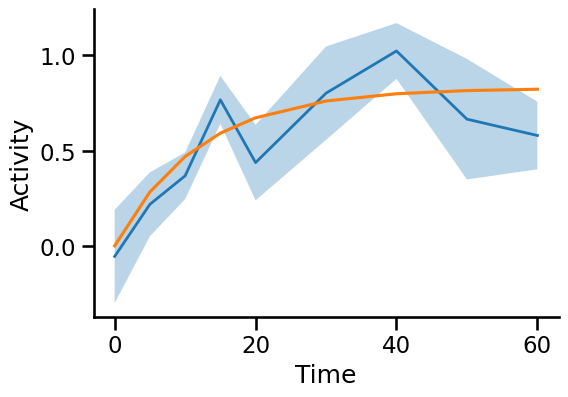

In [1173]:
# select your sequence
seq = "PSRLISTPKDGNSILRKWQTPSHLFEDLYCSPLFRAIETP"
data = active_tile_activities_count_filtered[active_tile_activities_count_filtered["ADseq"] == seq]

t = data["time"].values
y = data["activity"].values
yerr = data["error"].values if "error" in data else np.zeros_like(y)

plt.figure(figsize=(6,4))

# shaded error behind line
plt.fill_between(t, y - yerr, y + yerr, alpha=0.3, zorder=1)

# main line
sns.lineplot(x=t, y=y, linewidth=2, zorder=2)
sns.lineplot(x=t, y=df_best_fit[df_best_fit["ADseq"] == seq]["y_pred"].iloc[0])

sns.despine()
plt.xlabel("Time")
plt.ylabel("Activity")
plt.show()

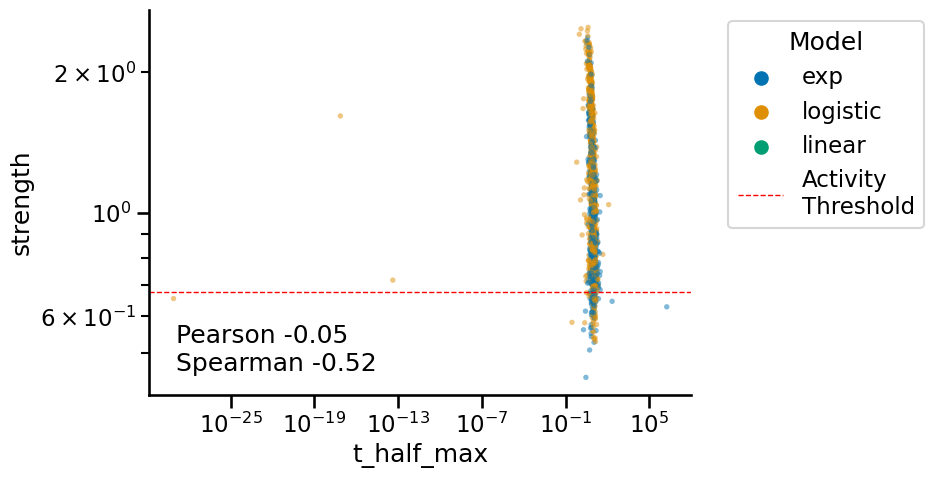

In [648]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr, spearmanr

# Define a fixed palette for all models
models = df_best_fit_filtered['model'].unique()
palette = sns.color_palette("colorblind", len(models))
model_palette = dict(zip(models, palette))  # map model -> color

# ------------------------
# Pearson correlation for all data (first plot)
# ------------------------
df_all = df_best_fit_filtered.dropna()
log_t_half_all = np.log10(df_all["t_half_max"])
log_strength_all = np.log10(df_all["strength"])

pearson_corr_all, _ = pearsonr(log_t_half_all, log_strength_all)
spearman_corr_all, _ = spearmanr(log_t_half_all, log_strength_all)

# ------------------------
# First scatter plot (all data, no xlim)
# ------------------------
plt.figure(figsize=(7,5))
ax1 = sns.scatterplot(
    data=df_best_fit_filtered,
    x="t_half_max",
    y="strength",
    hue="model",
    palette=model_palette,
    edgecolor="none",
    alpha=0.5,
    s=15
)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.axhline(threshold, color='red', linestyle='--', linewidth=1, label="Activity\nThreshold")

# Annotate Pearson & Spearman correlation for all data
ax1.text(
    0.05, 0.05,
    f"Pearson {pearson_corr_all:.2f}\nSpearman {spearman_corr_all:.2f}",
    transform=ax1.transAxes,
    fontsize='medium',
    verticalalignment='bottom',
    horizontalalignment='left'
)

ax1.legend(title="Model", loc='upper right', bbox_to_anchor=(1.45,1))
sns.despine()
plt.show()



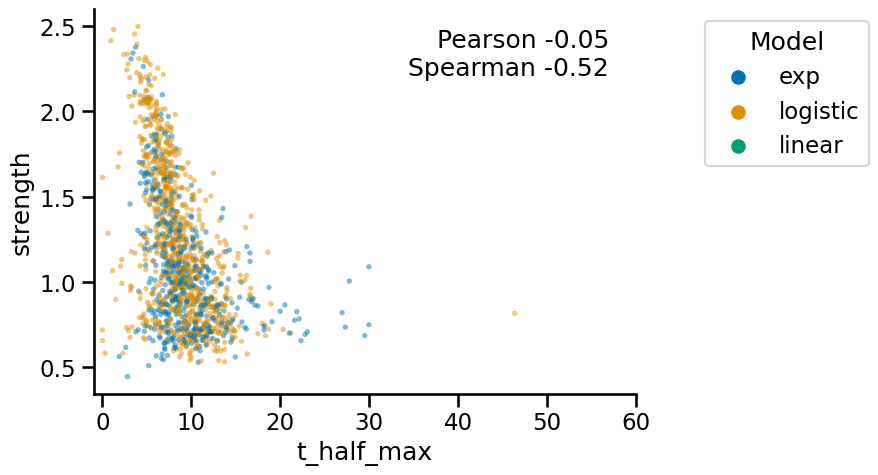

In [649]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr, spearmanr

# Define a fixed palette for all models
models = df_best_fit_filtered['model'].unique()
palette = sns.color_palette("colorblind", len(models))
model_palette = dict(zip(models, palette))  # map model -> color

# ------------------------
# Pearson correlation for all data (first plot)
# ------------------------
df_all = df_best_fit_filtered.dropna()
log_t_half_all = np.log10(df_all["t_half_max"])
log_strength_all = np.log10(df_all["strength"])

pearson_corr_all, _ = pearsonr(log_t_half_all, log_strength_all)
spearman_corr_all, _ = spearmanr(log_t_half_all, log_strength_all)

# ------------------------
# First scatter plot (all data)
# ------------------------
plt.figure(figsize=(7,5))
ax1 = sns.scatterplot(
    data=df_best_fit_filtered,
    x="t_half_max",
    y="strength",
    hue="model",
    palette=model_palette,
    edgecolor="none",
    alpha=0.5,
    s=15
)

ax1.set_xlim(-1, 60)

# Annotate Pearson correlation for all data
ax1.text(
    0.95, 0.95,
    f"Pearson {pearson_corr_all:.2f}\nSpearman {spearman_corr_all:.2f}",
    transform=ax1.transAxes,
    fontsize='medium',
    verticalalignment='top',
horizontalalignment='right'
)

ax1.legend(title="Model", loc = 'upper right', bbox_to_anchor = (1.45,1))
sns.despine()
plt.show()



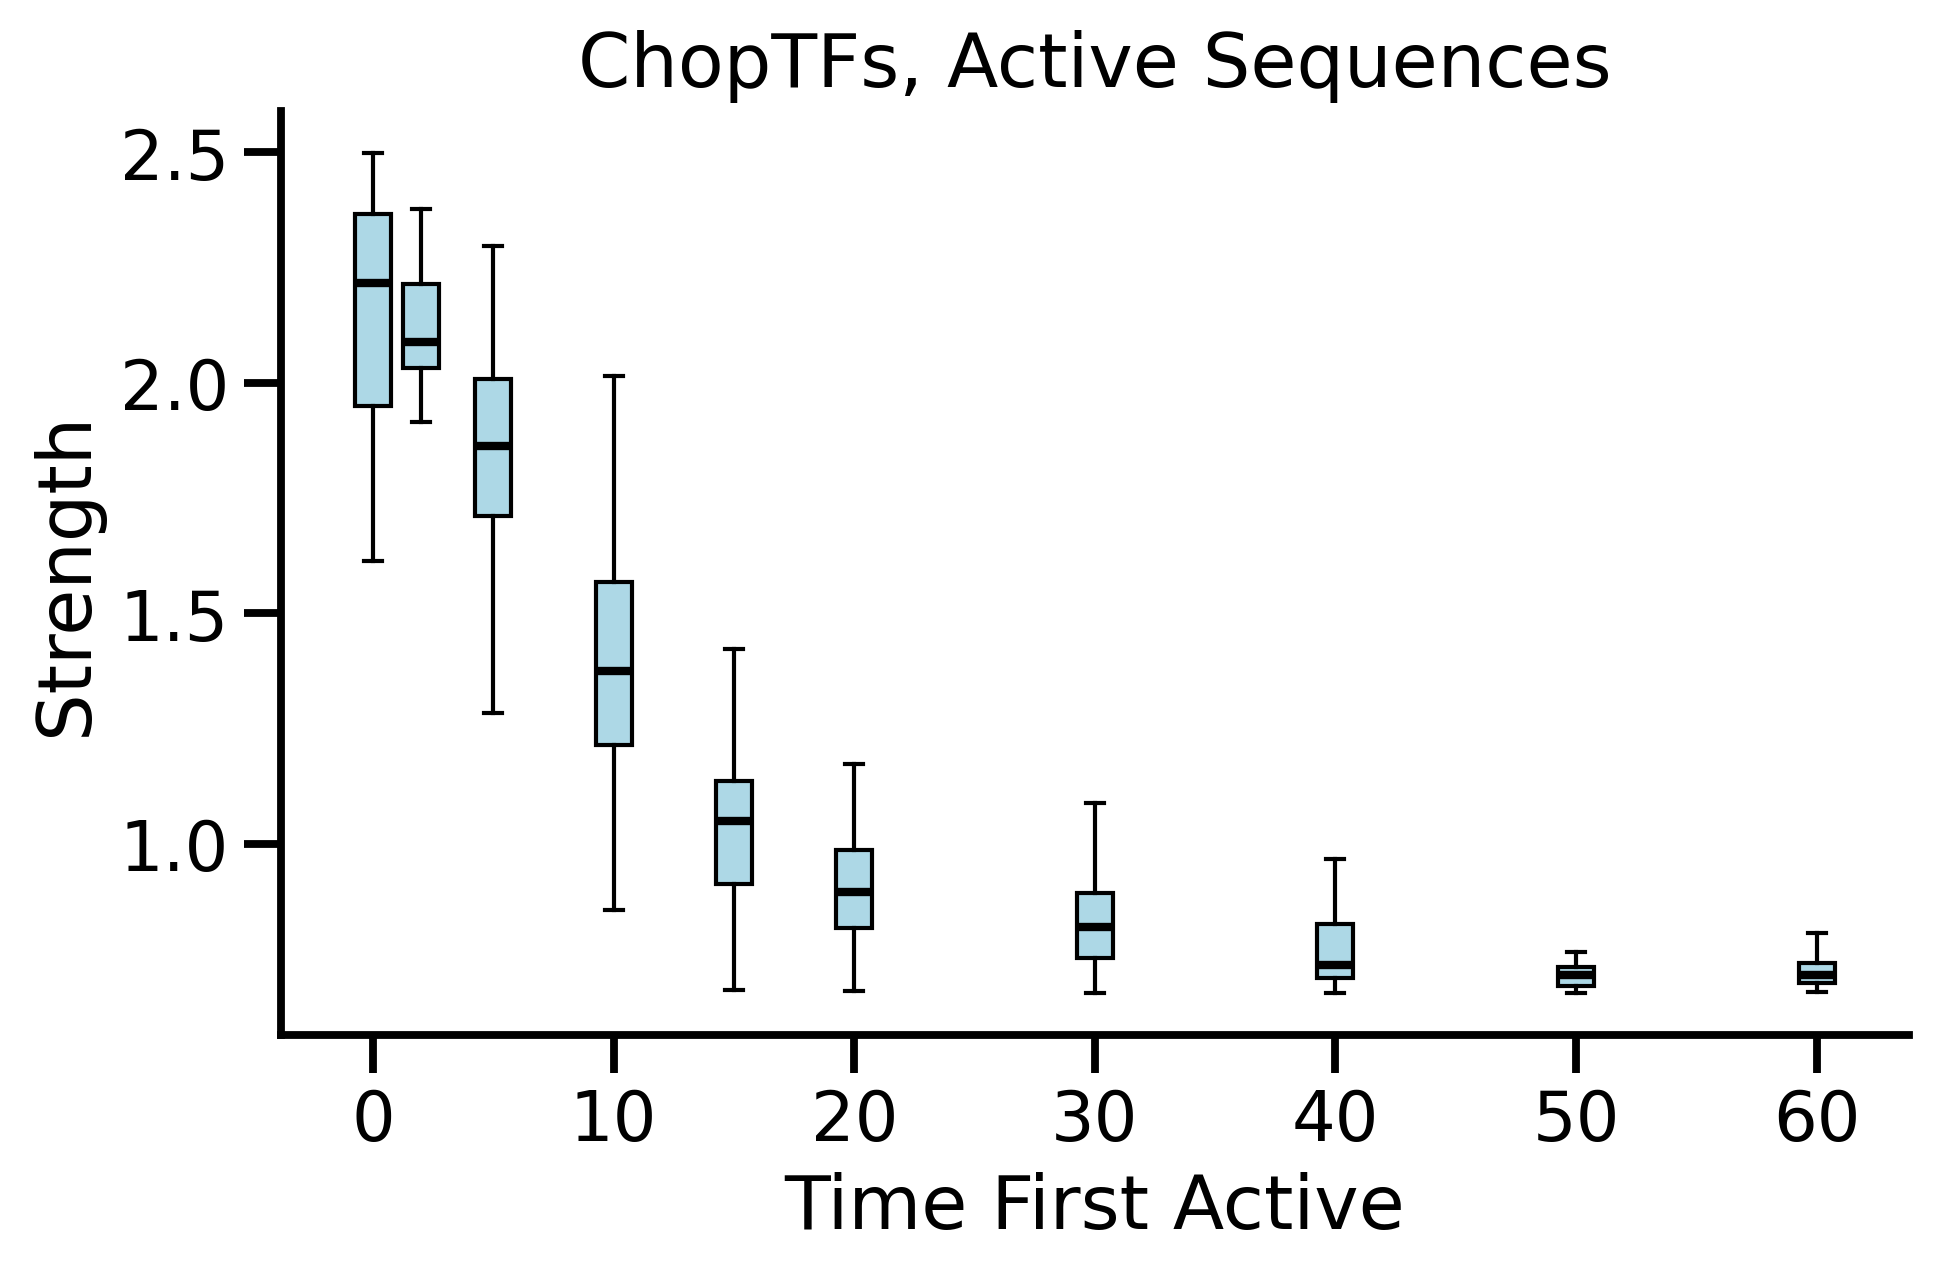

In [650]:
sns.set_context('talk')
plt.figure(figsize=(7,4), dpi = 300)  # light gray background

# Sort unique activation_times
plot_df = df_best_fit_filtered[df_best_fit_filtered["strength"] > threshold]
x_vals = np.sort(plot_df['activation_time'].unique())
data_to_plot = [plot_df[plot_df['activation_time']==x]['strength'] for x in x_vals]

# Boxplot with wider boxes, no fliers, colored boxes, black median line
plt.boxplot(
    data_to_plot,
    positions=x_vals,
    widths=1.5,
    showfliers=False,
    patch_artist=True,                # allow facecolor
    boxprops=dict(facecolor='#add8e6', color='black', linewidth=1),  # light blue fill, black border
    medianprops=dict(color='black', linewidth=2),                     # black median line
    whiskerprops=dict(color='black', linewidth=1),
    capprops=dict(color='black', linewidth=1)
)

# Horizontal threshold line

# Set x-axis ticks to multiples of 10 that are actually in the data
ticks = x_vals[x_vals % 10 == 0]
plt.xticks(ticks, [str(int(t)) for t in ticks])
plt.title("ChopTFs, Active Sequences")
plt.xlabel("Time First Active")
plt.ylabel("Strength")
sns.despine()
plt.show()

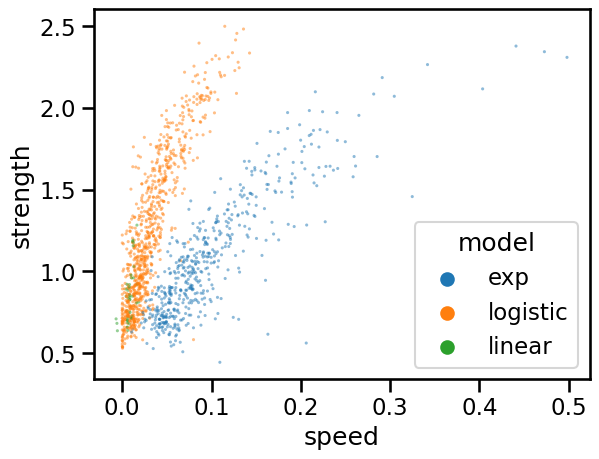

In [651]:
ax = sns.scatterplot(data = df_best_fit_filtered, x = "speed", y = "strength", hue = 'model', edgecolor = 'none', alpha = 0.5, s = 5)
